# Creating figures for the presentation    

## setup 

In [5]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Your directory with the chunked CSVs
DATA_DIR = Path(r"D:/Coding Projects/AI-in-Drug-Discovery-/presentation_figs/V5_Data")
FIG_DIR  = DATA_DIR / "figures_chunked"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# consistent colors for your classes
CLASS_COLORS = {"inward": "#4CAF50", "occluded": "#FF9800", "outward": "#F44336"}

# Matplotlib styling
plt.rcParams.update({
    "figure.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})
sns.set_context("talk", font_scale=0.9)


## Load CSV

In [6]:
def load_chunked_csvs(folder: Path):
    csvs = sorted(folder.glob("*_chunked_*.csv")) or sorted(folder.glob("*.csv"))
    dfs  = []
    for p in csvs:
        df = pd.read_csv(p)
        # normalize expected columns
        rename = {
            "start_fram": "start_frame",
            "end_fram":   "end_frame",
            "winner_cl":  "winner_class",
        }
        for k,v in rename.items():
            if k in df.columns and v not in df.columns:
                df = df.rename(columns={k:v})
        # enforce types
        keep = ["chunk_id","start_frame","end_frame","max_conf","winner_class","true_class","pred_class"]
        missing = [c for c in keep if c not in df.columns]
        if missing:
            print(f"⚠️ {p.name}: missing columns {missing} — skipping")
            continue
        df["source_file"] = p.stem
        dfs.append(df)
    return dfs

dfs = load_chunked_csvs(DATA_DIR)
print(f"Loaded {len(dfs)} files")
if dfs: dfs[0].head()


Loaded 4 files


## Helper functions 

In [7]:
def title_from_name(name: str):
    # try to pull drug name from filename like cleaned_XYZ_predictions_chunked_20
    parts = name.replace(".csv","").split("_")
    for token in parts:
        if token.isalpha() and len(token) >= 3:
            return token.upper()
    return name

def savefig(fig, path: Path):
    fig.savefig(path, bbox_inches="tight", dpi=300)
    print("✓ Saved", path.name)


## Chunk timeline (true vs predicted bars)

✓ Saved AMP_20_timeline.png


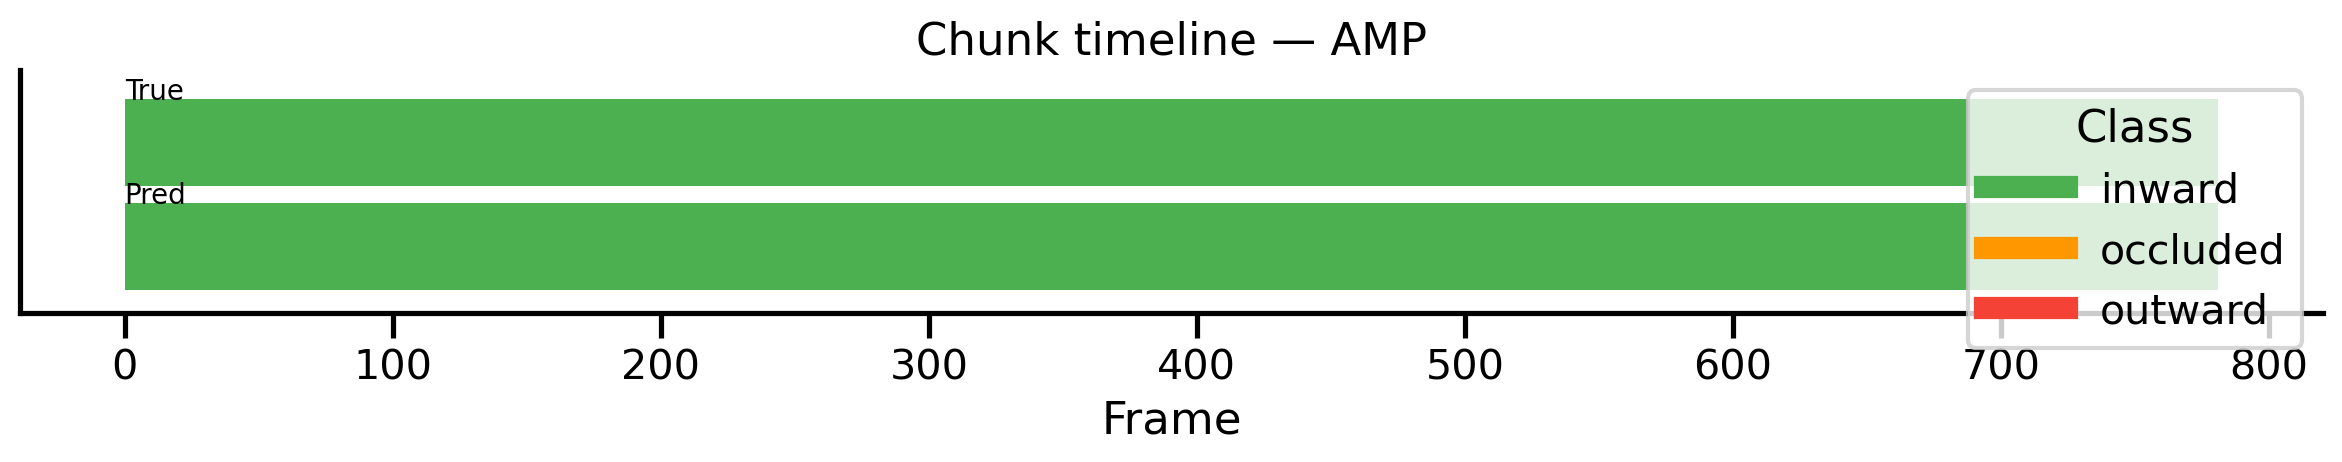

✓ Saved MAPB_20_timeline.png


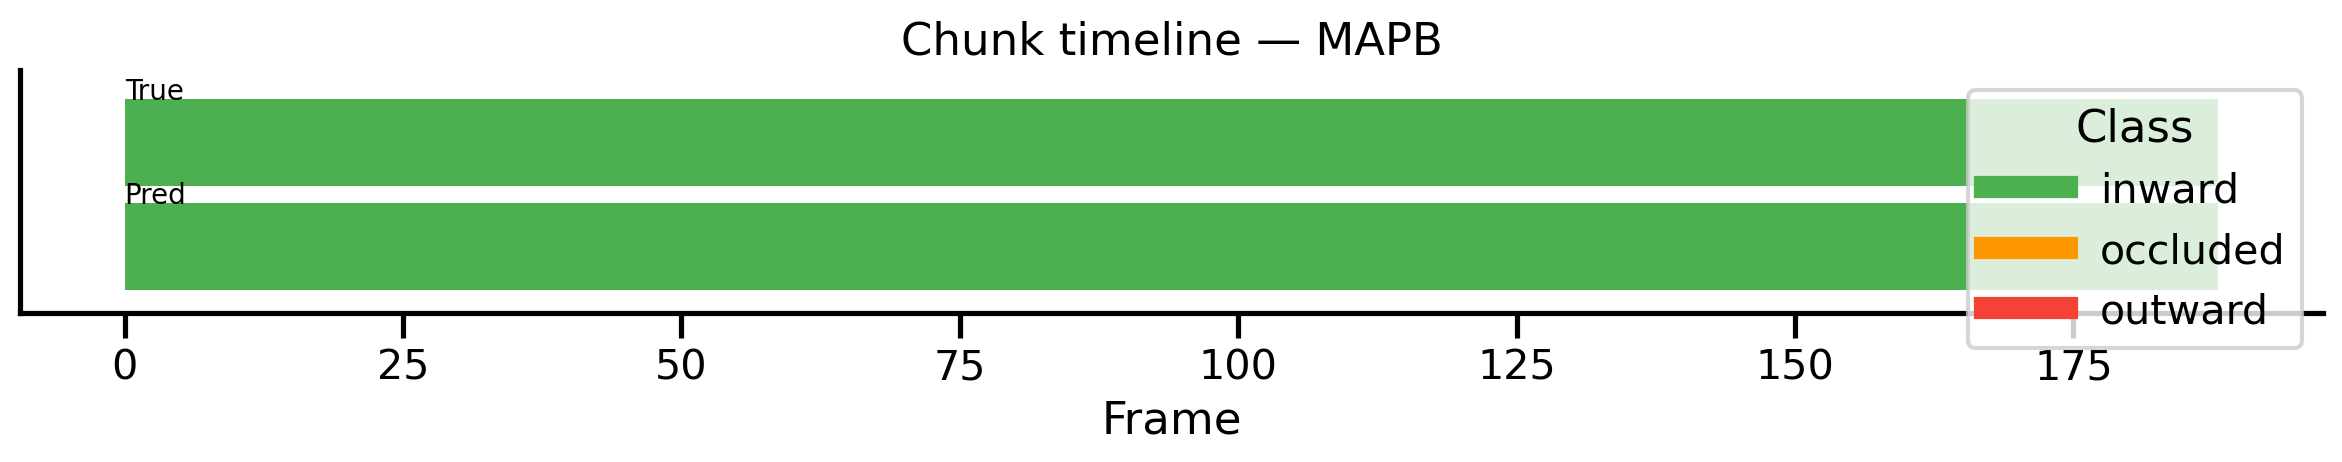

✓ Saved MDMA_20_timeline.png


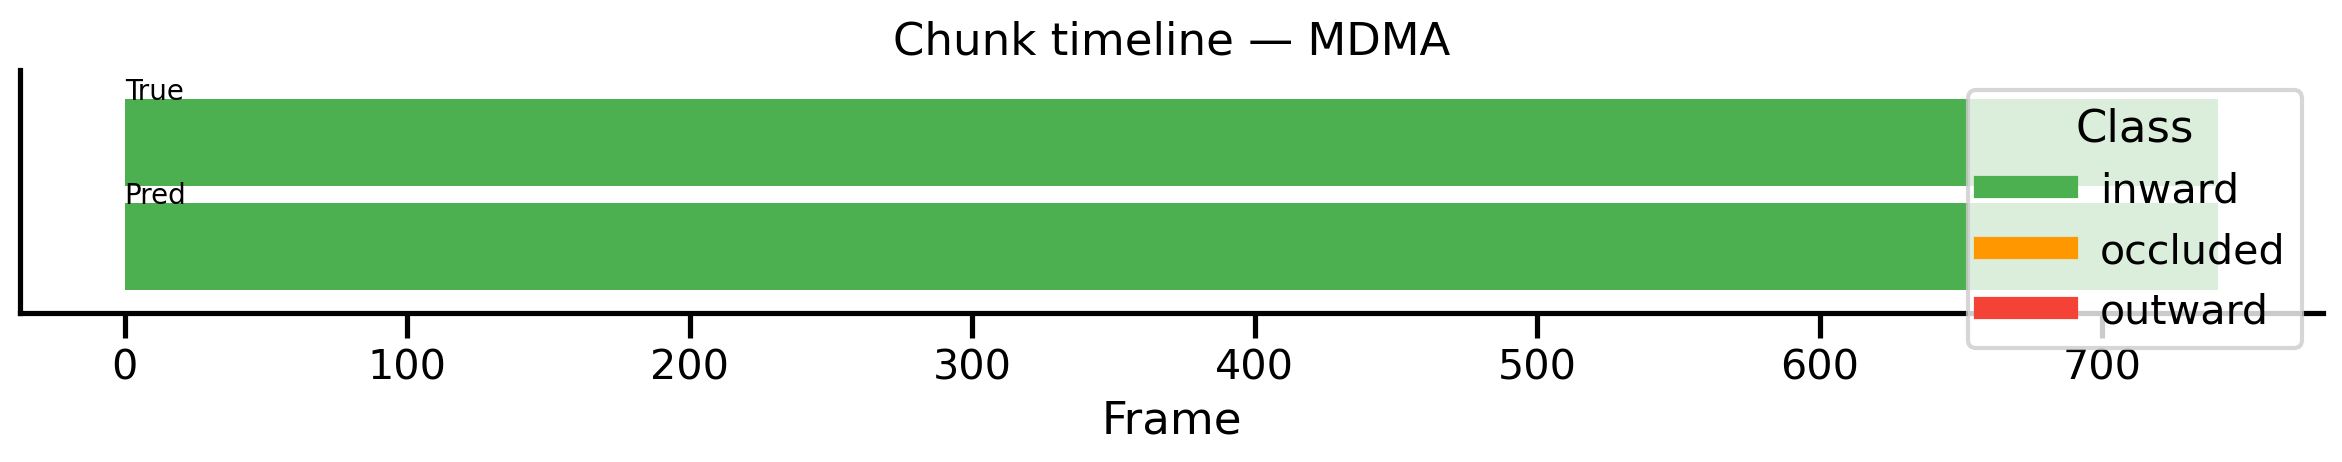

✓ Saved MPH_20_timeline.png


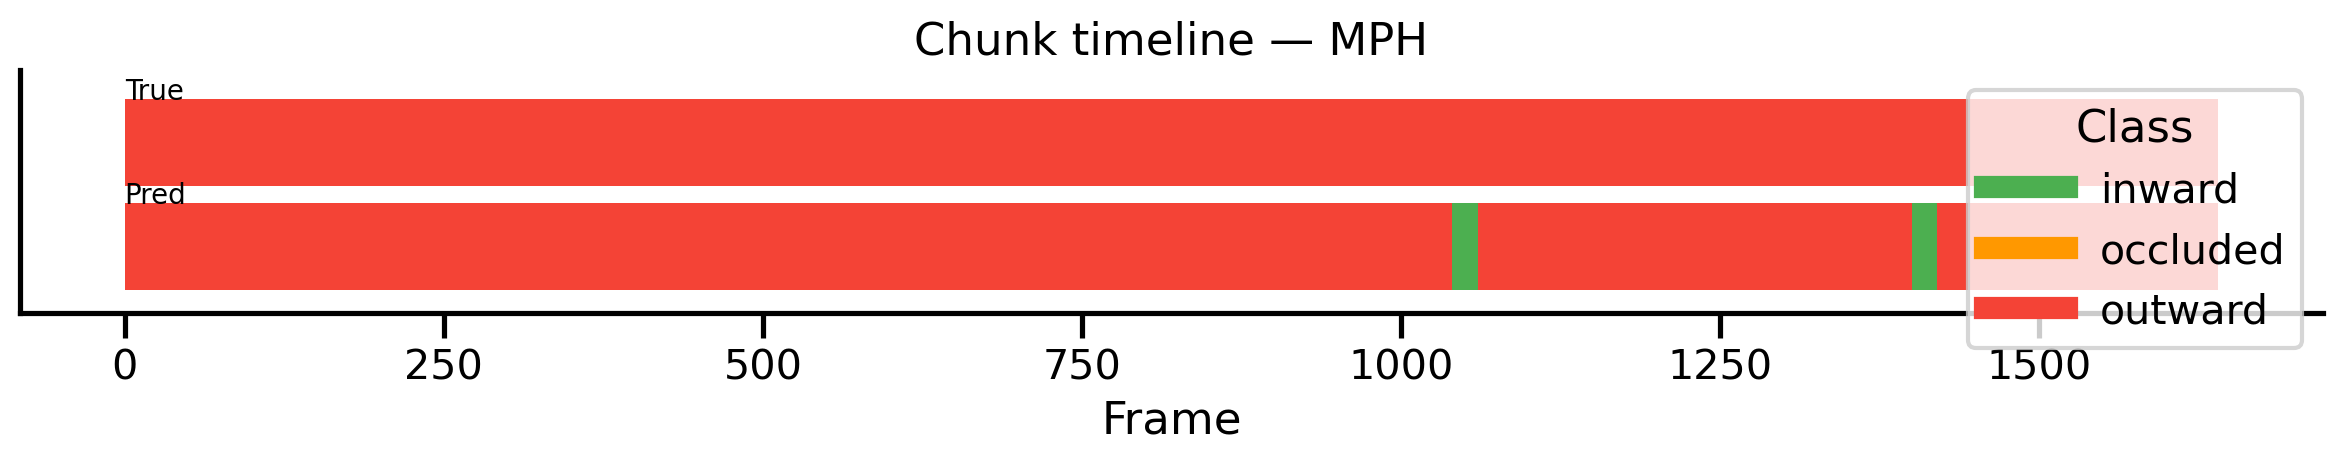

In [8]:
def plot_chunk_timeline(df, savepath=None):
    # Build broken-barh segments for pred and (if present) true
    def segments(labels, color_map):
        segs = []
        if len(labels)==0: return segs
        last = labels.iloc[0]; start = df["start_frame"].iloc[0]
        for i in range(1, len(labels)):
            if labels.iloc[i] != last:
                end = df["end_frame"].iloc[i-1]
                segs.append(((start, end-start+1), {"facecolor": color_map.get(last, "gray")}))
                last = labels.iloc[i]
                start = df["start_frame"].iloc[i]
        end = df["end_frame"].iloc[-1]
        segs.append(((start, end-start+1), {"facecolor": color_map.get(last, "gray")}))
        return segs

    fig, ax = plt.subplots(figsize=(12, 2.6))
    pred_seg = segments(df["pred_class"], CLASS_COLORS)
    for xr, stl in pred_seg: ax.broken_barh([xr], (0.2, 0.75), **stl)
    ax.set_yticks([]); ax.set_xlabel("Frame")
    ttl = f"Chunk timeline — {title_from_name(df['source_file'].iloc[0])}"
    ax.set_title(ttl)

    # Optional true bar if true_class not empty
    if (df["true_class"].astype(str) != "").any():
        true_seg = segments(df["true_class"], CLASS_COLORS)
        for xr, stl in true_seg: ax.broken_barh([xr], (1.1, 0.75), **stl)
        ax.text(df["start_frame"].min(), 1.85, "True", fontsize=10)
        ax.text(df["start_frame"].min(), 0.95, "Pred", fontsize=10)
        ax.set_ylim(0, 2.1)

    # legend
    handles = [plt.Line2D([0],[0], color=c, lw=8) for c in CLASS_COLORS.values()]
    ax.legend(handles, CLASS_COLORS.keys(), title="Class", loc="upper right")
    plt.tight_layout()
    if savepath: savefig(fig, savepath)
    plt.show()

for df in dfs:
    plot_chunk_timeline(df, savepath=FIG_DIR / f"{df['source_file'].iloc[0]}_timeline.png")


## Confidence trend per file (colored by predicted class)